In [ ]:
import pandas as pd

housing = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv')

housing

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,1565930130,20141104T000000,4,3.25,3760,4675,2.0,0,0,3,...,2740,1020,2007,0,98038,47.3862,-122.048,3280,4033,429900.0
1,3279000420,20150115T000000,3,1.75,1460,7800,1.0,0,0,2,...,1040,420,1979,0,98023,47.3035,-122.382,1310,7865,233000.0
2,194000575,20141014T000000,4,1.00,1340,5800,1.5,0,2,3,...,1340,0,1914,0,98116,47.5658,-122.389,1900,5800,455000.0
3,2115510160,20141208T000000,3,1.75,1440,8050,1.0,0,0,3,...,1440,0,1985,0,98023,47.3187,-122.390,1790,7488,258950.0
4,7522500005,20140815T000000,2,1.50,1780,4750,1.0,0,0,4,...,1080,700,1947,0,98117,47.6859,-122.395,1690,5962,555000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5272200045,20141113T000000,3,1.50,1000,6914,1.0,0,0,3,...,1000,0,1947,0,98125,47.7144,-122.319,1000,6947,378000.0
19996,9578500790,20141111T000000,3,2.50,3087,5002,2.0,0,0,3,...,3087,0,2014,0,98023,47.2974,-122.349,2927,5183,399950.0
19997,7202350480,20140930T000000,3,2.50,2120,4780,2.0,0,0,3,...,2120,0,2004,0,98053,47.6810,-122.032,1690,2650,575000.0
19998,1723049033,20140620T000000,1,0.75,380,15000,1.0,0,0,3,...,380,0,1963,0,98168,47.4810,-122.323,1170,15000,245000.0


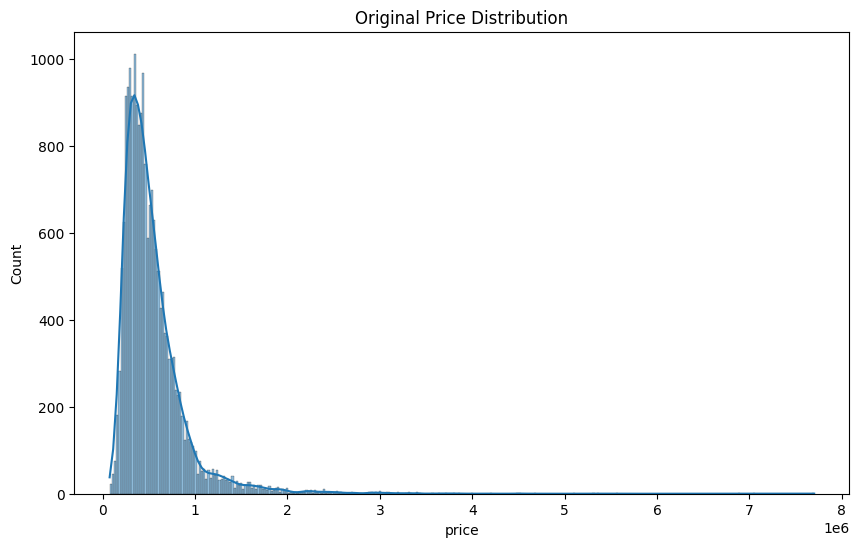

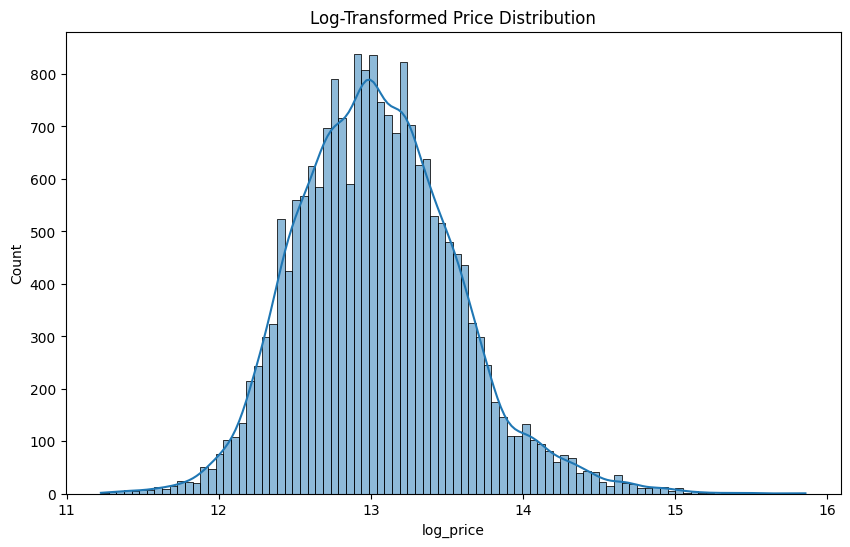

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(housing['price'], kde=True)
plt.title('Original Price Distribution')
plt.show()

housing['log_price'] = np.log1p(housing['price'])
plt.figure(figsize=(10, 6))
sns.histplot(housing['log_price'], kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()

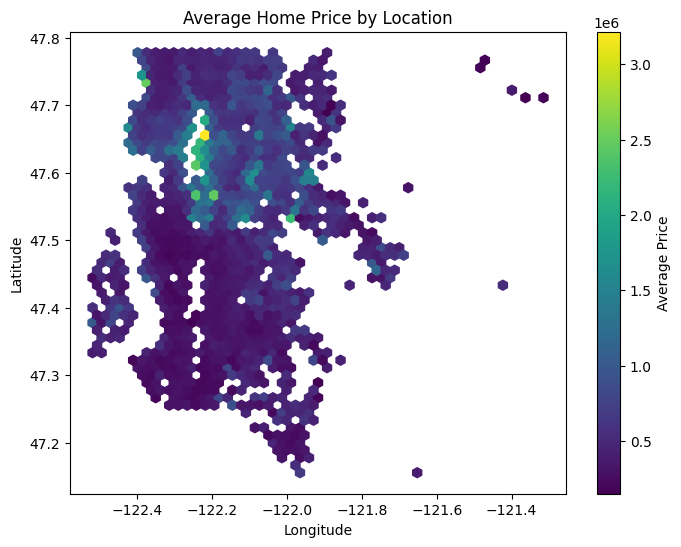

In [ ]:
plt.figure(figsize=(8, 6))

plt.hexbin(
    housing['long'],
    housing['lat'],
    C=housing['price'],
    reduce_C_function=np.mean,
    gridsize=50
)

plt.colorbar(label='Average Price')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average Home Price by Location")
plt.show()

In [ ]:
housing['date'] = pd.to_datetime(housing['date'])

housing['sold_month'] = housing['date'].dt.month

housing['house_age'] = housing['date'].dt.year - housing['yr_built']

housing['years_since_renovation'] = np.where(housing['yr_renovated'] > 0,
                                             housing['date'].dt.year - housing['yr_renovated'],
                                             housing['house_age'])

housing["neighborhood"] = housing["id"].astype(str).str[:6]

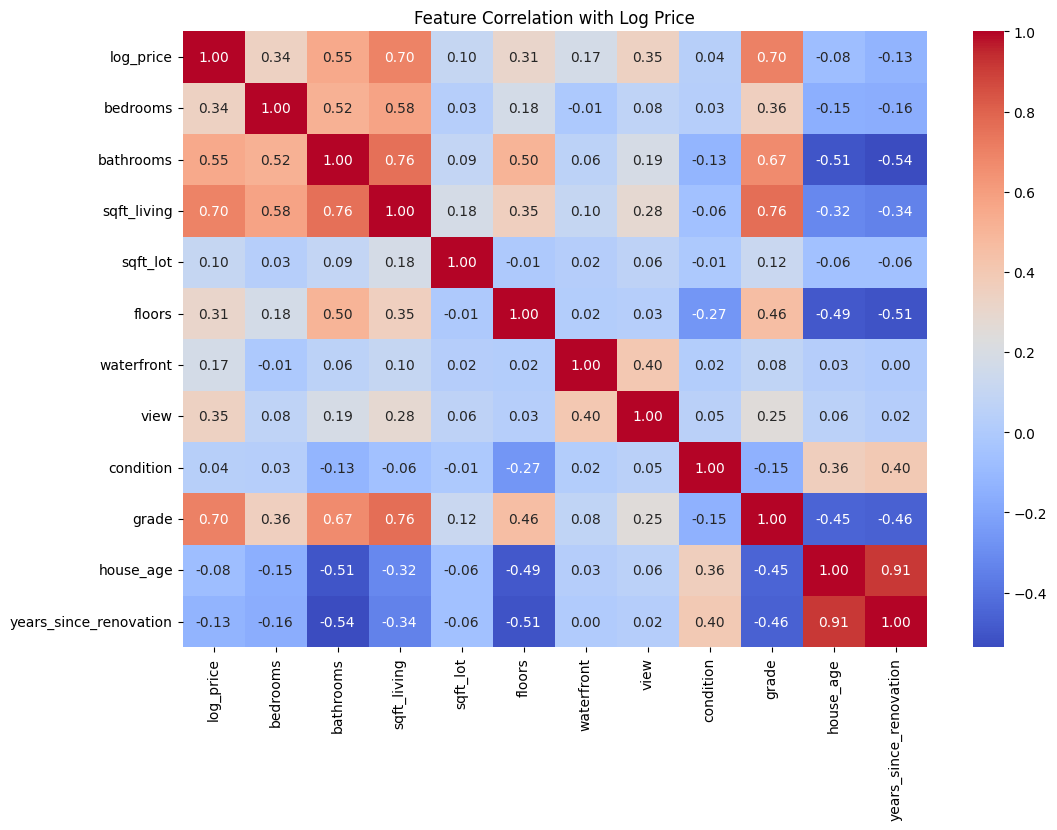

In [ ]:
cols_to_corr = ['log_price', 'bedrooms', 'bathrooms', 'sqft_living',
                'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
                'grade', 'house_age', 'years_since_renovation']

plt.figure(figsize=(12, 8))
sns.heatmap(housing[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Log Price')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import TargetEncoder

X = housing.drop(['price', 'log_price', 'date', 'id'], axis=1)
y = housing['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

target_cols = ['zipcode', 'neighborhood']

te = TargetEncoder(smooth='auto', random_state=42)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test_encoded[target_cols] = te.transform(X_test[target_cols])

model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    reg_alpha=0.01,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train_encoded, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
test_pred_log = model.predict(X_test_encoded)

test_pred_price = np.expm1(test_pred_log)
y_test_price = np.expm1(y_test)

test_rmse = root_mean_squared_error(y_test_price, test_pred_price)
test_r2 = r2_score(y_test_price, test_pred_price)

print(f"RMSE (dollars): {test_rmse}")
print(f"R^2 (dollars): {test_r2}")

RMSE (dollars): 120750.40974211632
R^2 (dollars): 0.903323037614867


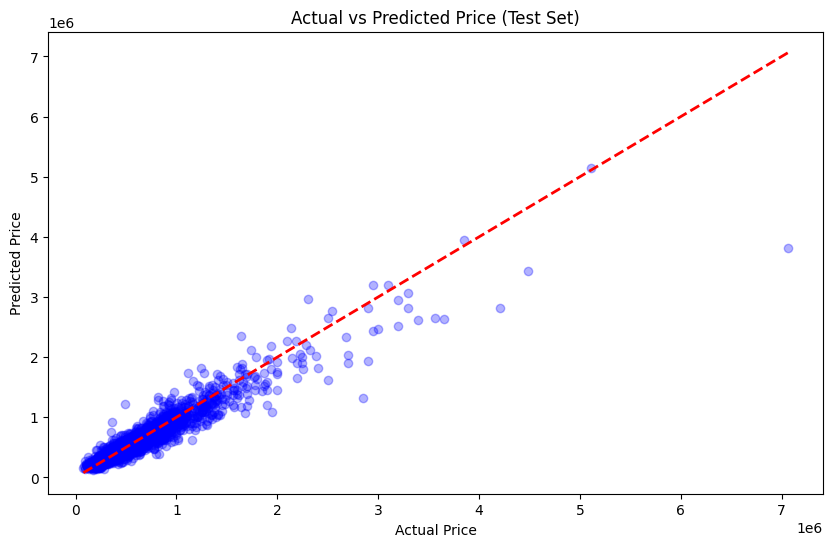

In [ ]:
def actual_pred_plot(y_actual, y_pred):
  plt.figure(figsize=(10, 6))
  plt.scatter(y_actual, y_pred, alpha=0.3, color='blue')
  plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
  plt.xlabel('Actual Price')
  plt.ylabel('Predicted Price')
  plt.title('Actual vs Predicted Price (Test Set)')
  plt.show()

actual_pred_plot(y_test_price, test_pred_price)

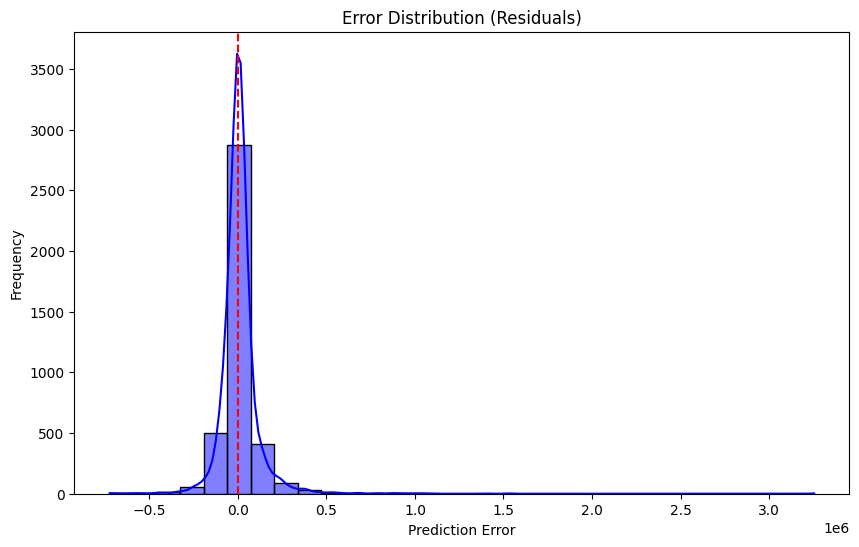

In [ ]:

def residuals_plot(y_actual, y_pred):
  residuals = y_actual - y_pred

  plt.figure(figsize=(10, 6))
  sns.histplot(residuals, kde=True, color='blue', bins=30)
  plt.axvline(x=0, color='red', linestyle='--')  # Zero error line
  plt.title('Error Distribution (Residuals)')
  plt.xlabel('Prediction Error')
  plt.ylabel('Frequency')
  plt.show()

residuals_plot(y_test_price, test_pred_price)

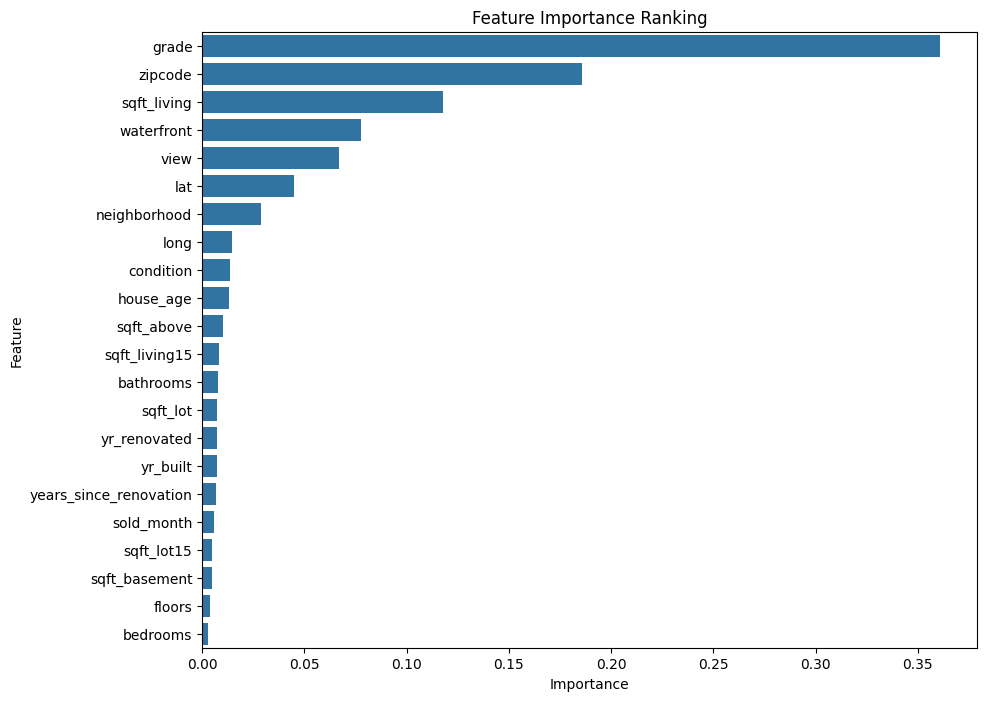

In [ ]:

def features_graph(model, X):

  importances = model.feature_importances_
  feature_names = X.columns
  feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

  feature_df = feature_df.sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10, 8))
  sns.barplot(x='Importance', y='Feature', data=feature_df)
  plt.title('Feature Importance Ranking')
  plt.show()

features_graph(model, X)

In [ ]:
holdout = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test.csv")

holdout['date'] = pd.to_datetime(holdout['date'])
holdout['sold_month'] = holdout['date'].dt.month
holdout['house_age'] = holdout['date'].dt.year - holdout['yr_built']
holdout['years_since_renovation'] = np.where(
    holdout['yr_renovated'] > 0,
    holdout['date'].dt.year - holdout['yr_renovated'],
    holdout['house_age']
)
holdout["neighborhood"] = holdout["id"].astype(str).str[:6]

holdout_encoded = holdout.copy()
holdout_encoded[target_cols] = te.transform(holdout[target_cols])

holdout_final = holdout_encoded[X_train.columns]

preds_log = model.predict(holdout_final)
preds_price = np.expm1(preds_log) * 1.031

pred_df = pd.DataFrame(preds_price, columns=["price"])
pred_df.to_csv("team3-module3-predictions.csv", index=False)